<a href="https://www.kaggle.com/code/lalit7881/consulting-readiness-analytics-dataset-eda-99?scriptVersionId=316385011" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mdmahfuzsumon/transforming-audit-insights-2-scalable-consulting/05_staff_profiles.csv
/kaggle/input/datasets/mdmahfuzsumon/transforming-audit-insights-2-scalable-consulting/06_training_records.csv
/kaggle/input/datasets/mdmahfuzsumon/transforming-audit-insights-2-scalable-consulting/README.md
/kaggle/input/datasets/mdmahfuzsumon/transforming-audit-insights-2-scalable-consulting/09_ethics_compliance.csv
/kaggle/input/datasets/mdmahfuzsumon/transforming-audit-insights-2-scalable-consulting/02_services.csv
/kaggle/input/datasets/mdmahfuzsumon/transforming-audit-insights-2-scalable-consulting/07_time_series.csv
/kaggle/input/datasets/mdmahfuzsumon/transforming-audit-insights-2-scalable-consulting/12_partnership_network.csv
/kaggle/input/datasets/mdmahfuzsumon/transforming-audit-insights-2-scalable-consulting/08_service_outcomes.csv
/kaggle/input/datasets/mdmahfuzsumon/transforming-audit-insights-2-scalable-consulting/03_audit_observations.csv
/kaggle/input/datasets/m

## Loading dataset

In [2]:
base_path = "/kaggle/input/datasets/mdmahfuzsumon/transforming-audit-insights-2-scalable-consulting/"

files = os.listdir(base_path)

dataframes = {}

for file in files:
    if file.endswith(".csv"):
        dataframes[file] = pd.read_csv(base_path + file)

# Access like:
dataframes["05_staff_profiles.csv"].head()

,staff_id,firm_id,role,experience_years,certifications,num_certifications,technical_score,risk_assessment_score,data_analytics_score,communication_score,consulting_readiness_score,industry_exposure,training_hours_ytd,is_bilingual,donor_project_experience
0,ST00001,F0331,Partner,18,"CFA,CPA,CFE",3,92.7,92.3,49.1,72.8,0.779,"Education,Manufacturing",68,False,False
1,ST00002,F0558,Senior Manager,15,"CFA,CMA",2,75.8,48.2,75.9,54.7,0.626,"Manufacturing,Technology,Insurance",100,True,True
2,ST00003,F0970,Staff Auditor,1,NaN,0,55.8,81.5,28.1,66.0,0.597,Agriculture,116,False,False
3,ST00004,F0126,Staff Auditor,0,CMA,1,49.6,28.4,45.3,54.7,0.450,"Energy & Utilities,Agriculture,Retail & Consumer",28,False,False
4,ST00005,F0051,Staff Auditor,1,"ACCA,CISA,CMA",3,79.2,61.2,71.7,66.1,0.693,"NGO & Development,Telecommunications,Transport...",97,True,False


In [3]:
for name, df in dataframes.items():
    print(f"\n{name}")
    print("-" * 40)
    print(df.shape)
    print(df.columns)
    print(df.info())


05_staff_profiles.csv
----------------------------------------
(5000, 15)
Index(['staff_id', 'firm_id', 'role', 'experience_years', 'certifications',
       'num_certifications', 'technical_score', 'risk_assessment_score',
       'data_analytics_score', 'communication_score',
       'consulting_readiness_score', 'industry_exposure', 'training_hours_ytd',
       'is_bilingual', 'donor_project_experience'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   staff_id                    5000 non-null   object 
 1   firm_id                     5000 non-null   object 
 2   role                        5000 non-null   object 
 3   experience_years            5000 non-null   int64  
 4   certifications              3715 non-null   object 
 5   num_certifications          5000 non-null   int64  
 6   

In [4]:
for name, df in dataframes.items():
    print(f"\n{name}")
    print(df.isnull().sum())


05_staff_profiles.csv
staff_id                         0
firm_id                          0
role                             0
experience_years                 0
certifications                1285
num_certifications               0
technical_score                  0
risk_assessment_score            0
data_analytics_score             0
communication_score              0
consulting_readiness_score       0
industry_exposure                0
training_hours_ytd               0
is_bilingual                     0
donor_project_experience         0
dtype: int64

06_training_records.csv
training_id             0
staff_id                0
firm_id                 0
year                    0
training_topic          0
training_method         0
training_hours          0
trainer_level           0
pre_training_score      0
post_training_score     0
effectiveness_score     0
certification_linked    0
isqm1_aligned           0
ethics_component        0
dtype: int64

09_ethics_compliance.csv
ethics_id  

In [5]:
df.fillna(0, inplace=True)

In [6]:
df.drop_duplicates(inplace=True)

## EDA

Staff Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   staff_id                    5000 non-null   object 
 1   firm_id                     5000 non-null   object 
 2   role                        5000 non-null   object 
 3   experience_years            5000 non-null   int64  
 4   certifications              3715 non-null   object 
 5   num_certifications          5000 non-null   int64  
 6   technical_score             5000 non-null   float64
 7   risk_assessment_score       5000 non-null   float64
 8   data_analytics_score        5000 non-null   float64
 9   communication_score         5000 non-null   float64
 10  consulting_readiness_score  5000 non-null   float64
 11  industry_exposure           5000 non-null   object 
 12  training_hours_ytd          5000 non-null   int64  
 13  is_bilingual    

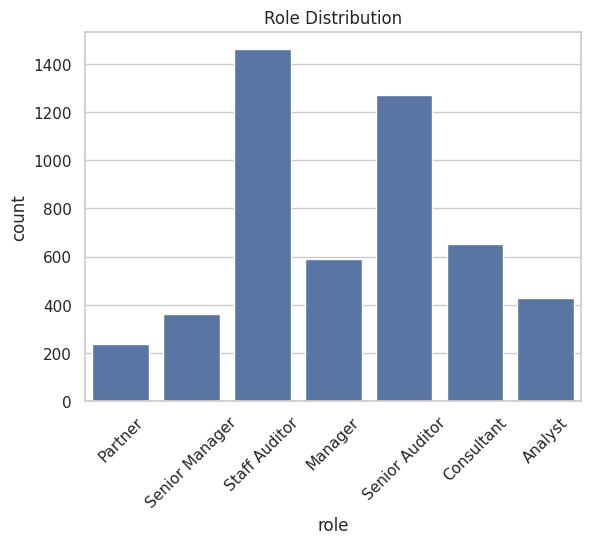

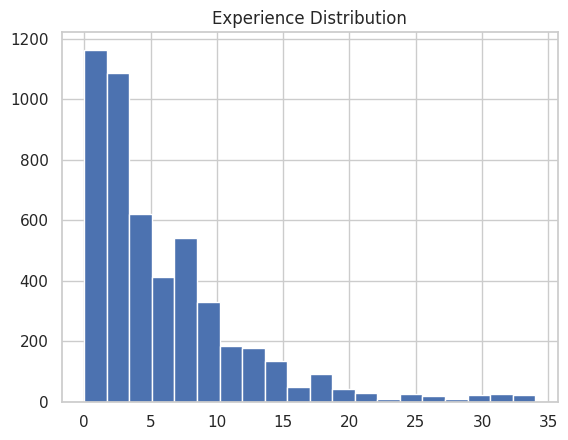

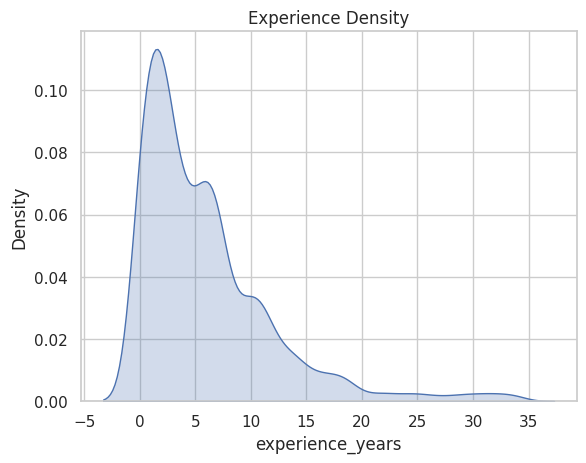

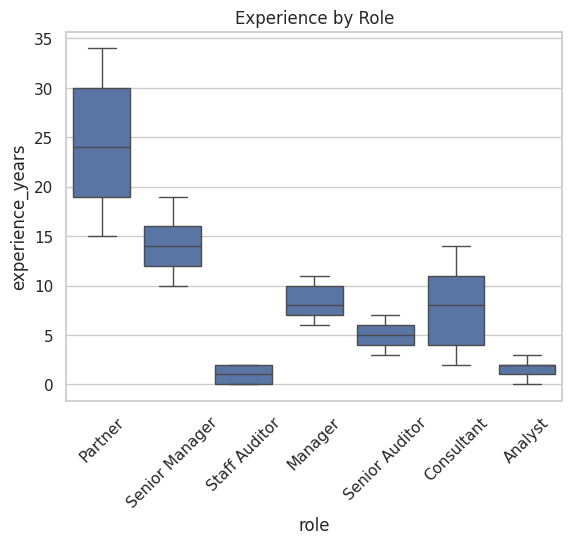

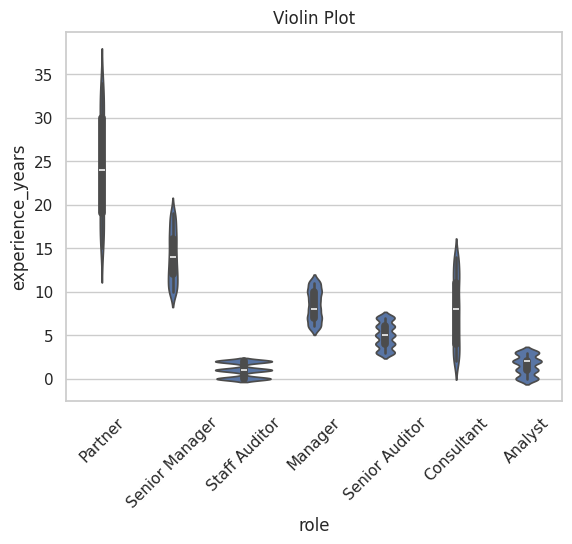

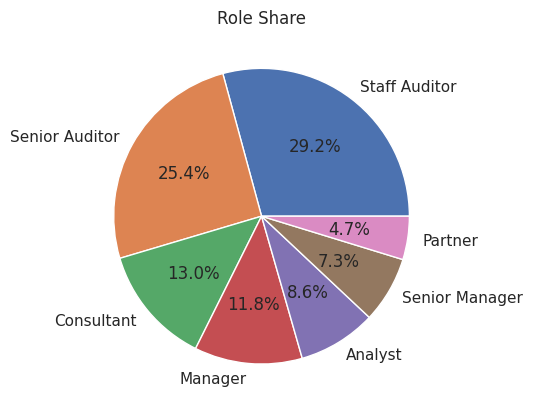

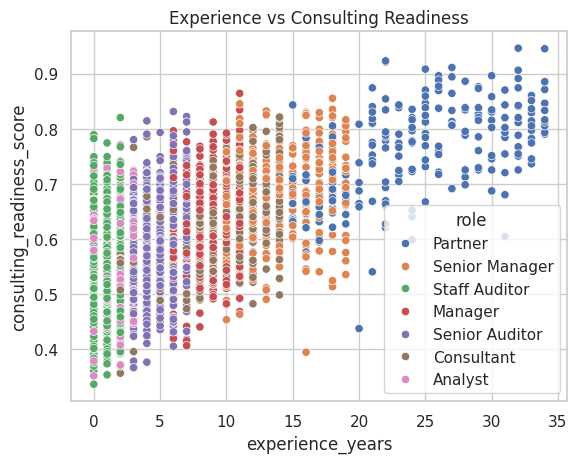

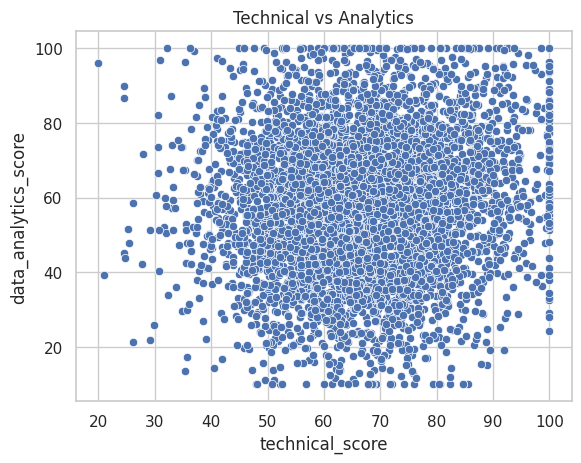

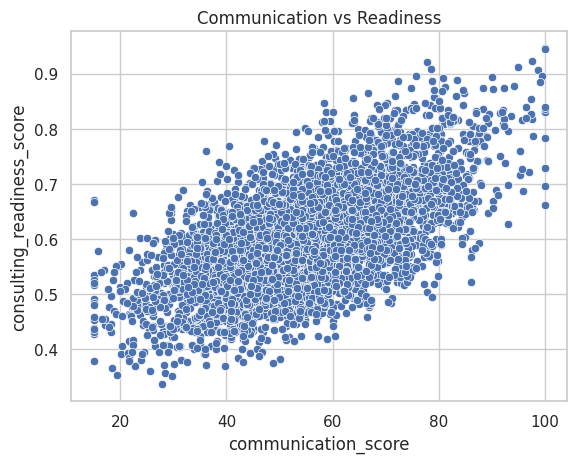

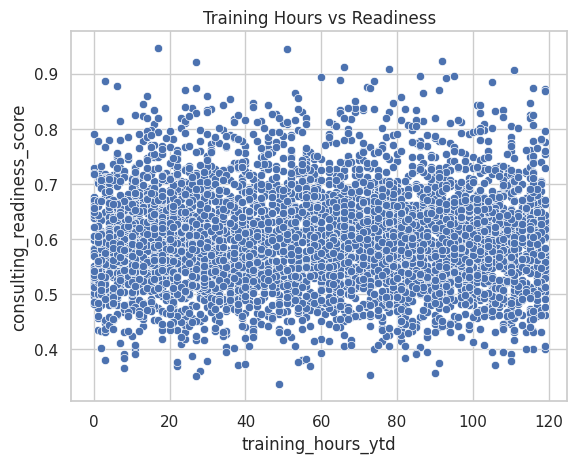

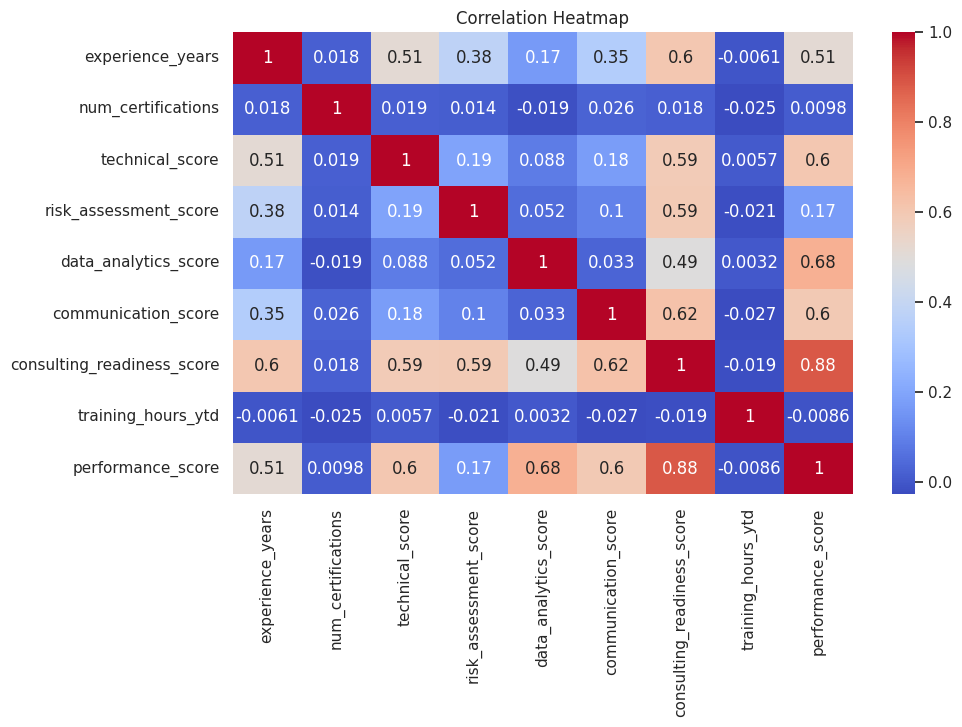

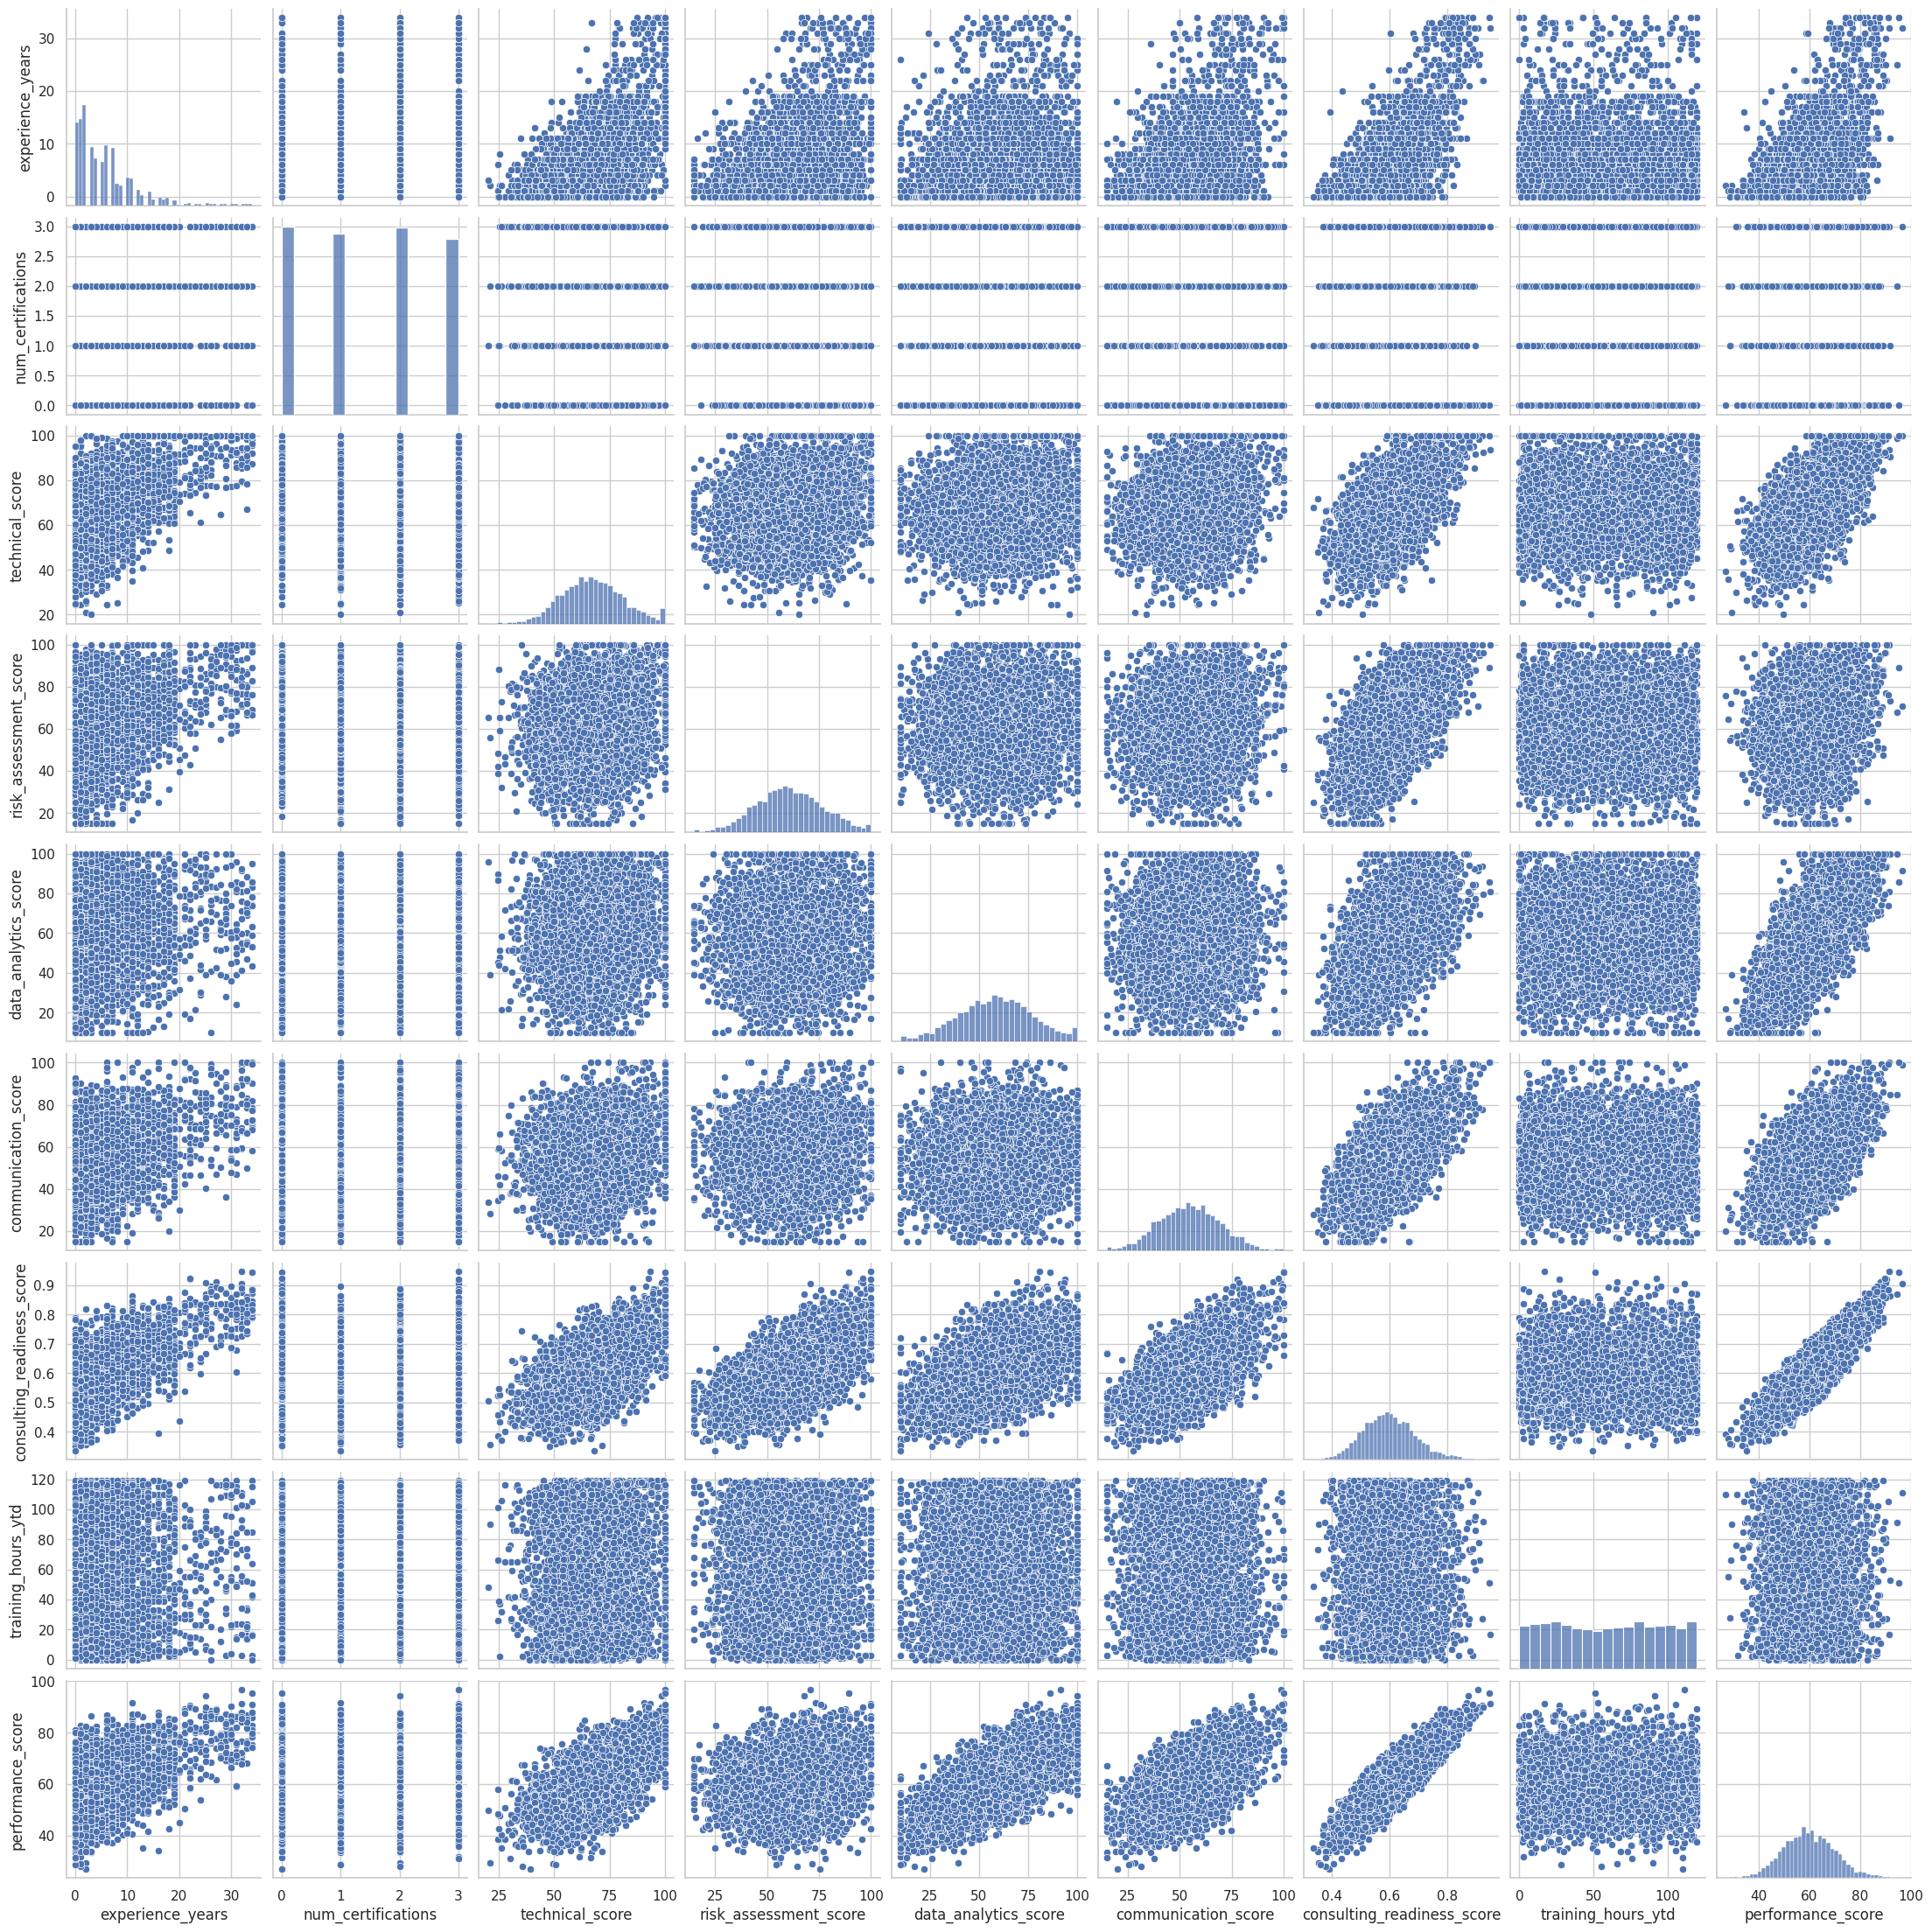

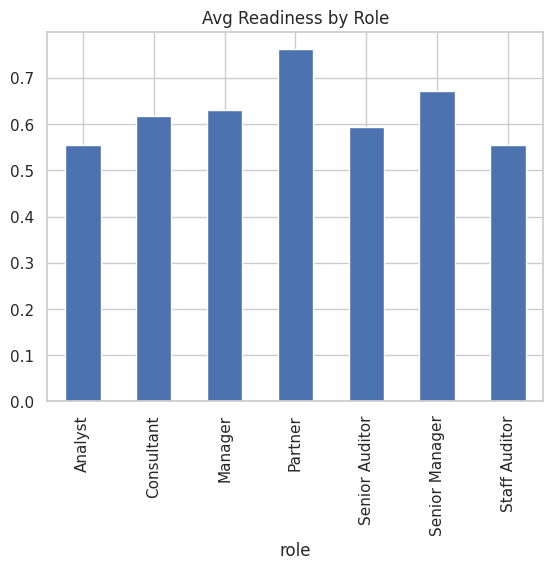

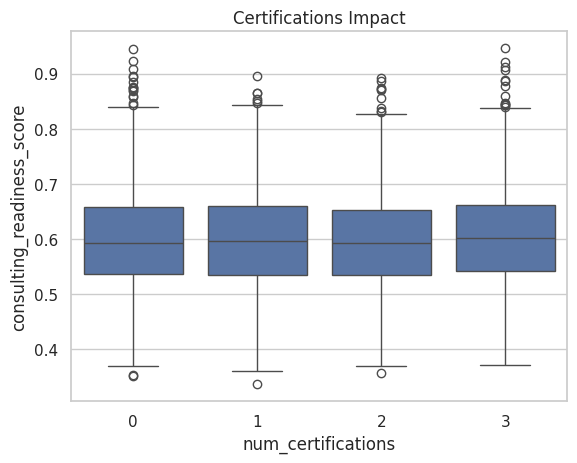

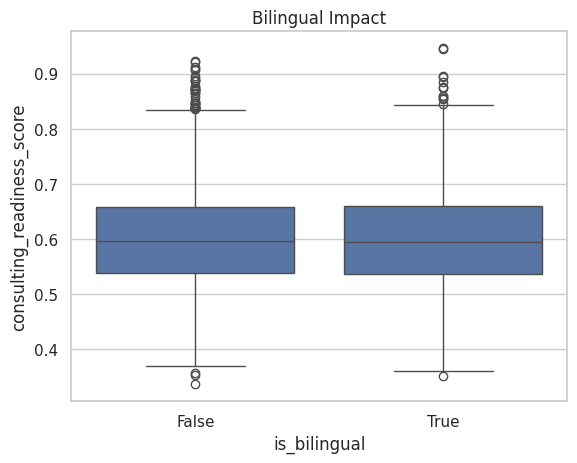

EDA Completed Successfully ✅


In [7]:
import os

sns.set(style="whitegrid")

# ==========================================
# 2. LOAD DATA
# ==========================================
base_path = "/kaggle/input/datasets/mdmahfuzsumon/transforming-audit-insights-2-scalable-consulting/"

dataframes = {}

for file in os.listdir(base_path):
    if file.endswith(".csv"):
        df = pd.read_csv(base_path + file)
        df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")
        dataframes[file] = df

# Select datasets
df_staff = dataframes["05_staff_profiles.csv"]
df_training = dataframes["06_training_records.csv"]
df_time = dataframes["07_time_series.csv"]
df_services = dataframes["02_services.csv"]

# ==========================================
# 3. BASIC INFO
# ==========================================
print("Staff Data Info:")
print(df_staff.info())
print(df_staff.describe())

# ==========================================
# 4. DATA CLEANING
# ==========================================

# Missing values
print("\nMissing Values:\n", df_staff.isnull().sum())

# Fill missing numeric values
df_staff.fillna(df_staff.median(numeric_only=True), inplace=True)

# Remove duplicates
df_staff.drop_duplicates(inplace=True)

# ==========================================
# 5. FEATURE ENGINEERING
# ==========================================
df_staff['performance_score'] = (
    df_staff['technical_score'] +
    df_staff['data_analytics_score'] +
    df_staff['communication_score']
) / 3

# ==========================================
# 6. VISUALIZATIONS
# ==========================================

# 1. Role Distribution
plt.figure()
sns.countplot(x='role', data=df_staff)
plt.xticks(rotation=45)
plt.title("Role Distribution")
plt.show()

# 2. Experience Histogram
plt.figure()
df_staff['experience_years'].hist(bins=20)
plt.title("Experience Distribution")
plt.show()

# 3. Experience KDE
plt.figure()
sns.kdeplot(df_staff['experience_years'], fill=True)
plt.title("Experience Density")
plt.show()

# 4. Boxplot Experience by Role
plt.figure()
sns.boxplot(x='role', y='experience_years', data=df_staff)
plt.xticks(rotation=45)
plt.title("Experience by Role")
plt.show()

# 5. Violin Plot
plt.figure()
sns.violinplot(x='role', y='experience_years', data=df_staff)
plt.xticks(rotation=45)
plt.title("Violin Plot")
plt.show()

# 6. Pie Chart Role Share
plt.figure()
df_staff['role'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Role Share")
plt.ylabel("")
plt.show()

# 7. Scatter: Experience vs Readiness
plt.figure()
sns.scatterplot(
    x='experience_years',
    y='consulting_readiness_score',
    hue='role',
    data=df_staff
)
plt.title("Experience vs Consulting Readiness")
plt.show()

# 8. Scatter: Technical vs Analytics
plt.figure()
sns.scatterplot(
    x='technical_score',
    y='data_analytics_score',
    data=df_staff
)
plt.title("Technical vs Analytics")
plt.show()

# 9. Scatter: Communication vs Readiness
plt.figure()
sns.scatterplot(
    x='communication_score',
    y='consulting_readiness_score',
    data=df_staff
)
plt.title("Communication vs Readiness")
plt.show()

# 10. Scatter: Training vs Readiness
plt.figure()
sns.scatterplot(
    x='training_hours_ytd',
    y='consulting_readiness_score',
    data=df_staff
)
plt.title("Training Hours vs Readiness")
plt.show()

# 11. Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    df_staff.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

# 12. Pairplot
sns.pairplot(df_staff.select_dtypes(include=np.number))
plt.show()

# 13. Avg Readiness by Role
plt.figure()
df_staff.groupby('role')['consulting_readiness_score'].mean().plot(kind='bar')
plt.title("Avg Readiness by Role")
plt.show()

# 14. Certifications vs Readiness
plt.figure()
sns.boxplot(
    x='num_certifications',
    y='consulting_readiness_score',
    data=df_staff
)
plt.title("Certifications Impact")
plt.show()

# 15. Bilingual Impact
plt.figure()
sns.boxplot(
    x='is_bilingual',
    y='consulting_readiness_score',
    data=df_staff
)
plt.title("Bilingual Impact")
plt.show()

# ==========================================
# TRAINING DATA VISUALS
# ==========================================

if 'training_type' in df_training.columns:
    plt.figure()
    sns.countplot(x='training_type', data=df_training)
    plt.xticks(rotation=45)
    plt.title("Training Types")
    plt.show()

if 'score' in df_training.columns:
    plt.figure()
    df_training.groupby('training_type')['score'].mean().plot(kind='bar')
    plt.title("Avg Training Score")
    plt.show()

# ==========================================
# TIME SERIES VISUALS
# ==========================================

if 'date' in df_time.columns:
    df_time['date'] = pd.to_datetime(df_time['date'], errors='coerce')

if 'value' in df_time.columns:
    plt.figure()
    df_time.groupby('date')['value'].sum().plot()
    plt.title("Time Series Trend")
    plt.show()

    plt.figure()
    df_time.set_index('date')['value'].rolling(7).mean().plot()
    plt.title("7-Day Rolling Avg")
    plt.show()

# ==========================================
# SERVICES VISUALS
# ==========================================

if 'service_type' in df_services.columns:
    plt.figure()
    sns.countplot(x='service_type', data=df_services)
    plt.xticks(rotation=45)
    plt.title("Service Types")
    plt.show()

# ==========================================
# DONE
# ==========================================
print("EDA Completed Successfully ✅")

## Feature engineering

Final dtypes:
 role                          int64
experience_years              int64
num_certifications            int64
technical_score             float64
risk_assessment_score       float64
data_analytics_score        float64
communication_score         float64
training_hours_ytd            int64
is_bilingual                  int64
donor_project_experience      int64
industry_exposure_count       int64
dtype: object

Logistic Regression
Accuracy: 0.991
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       499
           1       0.99      0.99      0.99       501

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000


Random Forest
Accuracy: 0.954
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       499
           1       0.95      0.96      0.95       501

    accuracy    

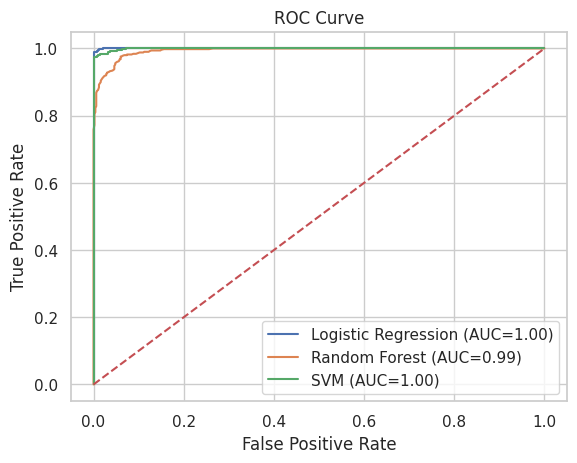

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, roc_curve, auc, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# ==========================================
# 2. LOAD DATA
# ==========================================
base_path = "/kaggle/input/datasets/mdmahfuzsumon/transforming-audit-insights-2-scalable-consulting/"
df = pd.read_csv(base_path + "05_staff_profiles.csv")

df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

# ==========================================
# 3. CLEANING
# ==========================================
df.fillna(df.median(numeric_only=True), inplace=True)

# ==========================================
# 4. TARGET
# ==========================================
threshold = df['consulting_readiness_score'].median()
df['target'] = (df['consulting_readiness_score'] >= threshold).astype(int)

# ==========================================
# 5. ENCODING
# ==========================================
le = LabelEncoder()
df['role'] = le.fit_transform(df['role'])

df['is_bilingual'] = df['is_bilingual'].astype(int)
df['donor_project_experience'] = df['donor_project_experience'].astype(int)

# ==========================================
# 🔥 6. FIX INDUSTRY COLUMN
# ==========================================
df['industry_exposure_count'] = df['industry_exposure'].apply(
    lambda x: len(str(x).split(','))
)

df.drop(columns=['industry_exposure'], inplace=True)

# ==========================================
# 7. DROP BAD COLUMNS
# ==========================================
df.drop(columns=[
    'staff_id',
    'firm_id',
    'certifications',
    'consulting_readiness_score'
], inplace=True)

# ==========================================
# 8. SPLIT
# ==========================================
X = df.drop(columns=['target'])
y = df['target']

print("Final dtypes:\n", X.dtypes)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 9. SCALING (NO LEAKAGE)
# ==========================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 10. MODELS
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(probability=True)
}

# ==========================================
# 11. TRAIN + EVALUATE
# ==========================================
plt.figure()

for name, model in models.items():
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

# ==========================================
# 12. ROC CURVE
# ==========================================
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Thank you...pls upvote!!!!!!